In [1]:
import pandas as pd

In [69]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

data = np.array([['Red'], ['Blue'], ['Green']])

encoder = OneHotEncoder()
encoded = encoder.fit_transform(data).toarray()

print(encoded)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [70]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
data1=np.array([['red'],['blue'],['green'],['red']])
encoder1 = OneHotEncoder()
encoded1 = encoder1.fit_transform(data1).toarray()
print(encoded1)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [71]:
from sklearn.preprocessing import OneHotEncoder

In [72]:
import numpy as np
import seaborn as sns
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [73]:
onehot= OneHotEncoder()
encoded3 = onehot.fit_transform(df.loc[:,['who']]).toarray()
print(encoded3)

[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [74]:
df.who.value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [75]:
new_features = onehot.get_feature_names_out()
new_features

array(['who_child', 'who_man', 'who_woman'], dtype=object)

In [76]:
df.loc[:,new_features] = encoded3

In [77]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,who_child,who_man,who_woman
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0.0,1.0,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.0,0.0,1.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0.0,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.0,0.0,1.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,0.0,1.0,0.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,0.0,0.0,1.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,0.0,0.0,1.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,0.0,1.0,0.0


In [78]:
df['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [79]:
new_class = onehot.fit_transform(df.loc[:,['class']]).toarray()
print(new_class)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [80]:
new_Features = onehot.get_feature_names_out()
new_Features

array(['class_First', 'class_Second', 'class_Third'], dtype=object)

In [81]:
df.loc[:,new_Features] = new_class

In [82]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,who_child,who_man,who_woman,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,0.0,1.0,0.0,0.0,0.0,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,0.0,0.0,1.0,1.0,0.0,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,0.0,0.0,1.0,1.0,0.0,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,...,NaN,Southampton,no,True,0.0,1.0,0.0,0.0,1.0,0.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,...,B,Southampton,yes,True,0.0,0.0,1.0,1.0,0.0,0.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,...,NaN,Southampton,no,False,0.0,0.0,1.0,0.0,0.0,1.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,...,C,Cherbourg,yes,True,0.0,1.0,0.0,1.0,0.0,0.0


In [83]:
df.sex.value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [84]:
new_col = onehot.fit_transform(df.loc[:,['sex']]).toarray()
print(new_col)

[[0. 1.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [85]:
new_feature1 = onehot.get_feature_names_out()

In [86]:
new_feature1

array(['sex_female', 'sex_male'], dtype=object)

In [87]:
df.loc[:,new_feature1] = new_col

In [88]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,alive,alone,who_child,who_man,who_woman,class_First,class_Second,class_Third,sex_female,sex_male
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,no,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,yes,False,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,yes,True,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,yes,False,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,no,True,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,...,no,True,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,...,yes,True,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,...,no,False,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,...,yes,True,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [89]:
df.alone.value_counts()

alone
True     537
False    354
Name: count, dtype: int64

In [90]:
alone = onehot.fit_transform(df.loc[:,['alone']]).toarray()

In [91]:
alone

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(891, 2))

In [92]:
new_feature2= onehot.get_feature_names_out()
new_feature2

array(['alone_False', 'alone_True'], dtype=object)

In [93]:
df.loc[:,new_feature2] = alone

In [94]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,who_child,who_man,who_woman,class_First,class_Second,class_Third,sex_female,sex_male,alone_False,alone_True
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [95]:
df1 = pd.read_csv('used_cars_data.csv')
df1.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [96]:
encode = OneHotEncoder()

In [97]:
df1.Transmission.value_counts()

Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64

In [98]:
transmission = encode.fit_transform(df.loc[:,['Owner_Type']]).toarray()
print(transmission)

KeyError: "None of [Index(['Owner_Type'], dtype='str')] are in the [columns]"

In [63]:
new_feature3= encode.get_feature_names_out()

NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

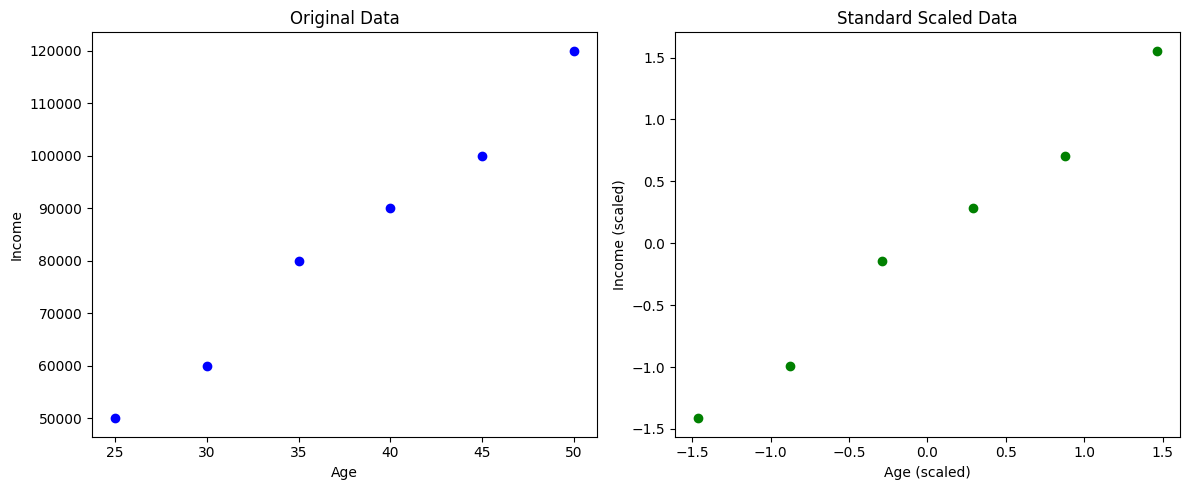

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Sample data: Age and Income
data = np.array([[25, 50000],
                 [30, 60000],
                 [35, 80000],
                 [40, 90000],
                 [45, 100000],
                 [50, 120000]])

# Original data
ages = data[:, 0]
income = data[:, 1]

# Standard Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_ages = scaled_data[:, 0]
scaled_income = scaled_data[:, 1]

# Plotting
plt.figure(figsize=(12,5))

# Original data
plt.subplot(1,2,1)
plt.scatter(ages, income, color='blue')
plt.title("Original Data")
plt.xlabel("Age")
plt.ylabel("Income")

# Scaled data
plt.subplot(1,2,2)
plt.scatter(scaled_ages, scaled_income, color='green')
plt.title("Standard Scaled Data")
plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")

plt.tight_layout()
plt.show()

In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.preprocessing import StandardScaler

In [ ]:
data = np.array([[25, 50000],
                 [30, 60000],
                 [35, 80000],
                 [40, 90000],
                 [45, 100000],
                 [50, 120000]])

ages = data[:,0]
salary = data[:,1]
scaler = StandardScaler()
scaled_data = scaler.ages